# Whitout balanced data 

In [20]:
import pandas as pd
import polars as pl


In [21]:
df = pd.read_csv("CDM_Dataset.csv")
df.head()

,Age,Gender,BMI,WaistCircumference,VisceralFat,FastingGlucose,PostprandialGlucose,HbA1c,InsulinLevel,InsulinResistance_HOMA,...,Uric_Acid,InflammationMarker_CRP,ThyroidTSH,VitaminD,Adiponectin,Leptin,OxygenSaturation,DietaryFiberIntake,CarbIntake_gday,CDM_Label
0,36.7,Female,28.0,85.6,10.0,145.0,263.7,7.43,13.54,4.848,...,5.45,0.69,0.598,11.4,3.53,7.47,94.2,6.9,264.0,0
1,59.4,Female,29.9,96.6,19.9,156.2,306.9,9.10,24.27,9.360,...,5.04,5.30,1.763,10.9,7.06,27.71,98.6,7.8,272.0,1
2,68.2,Female,33.1,110.2,10.8,127.7,174.0,8.46,33.63,10.604,...,6.71,3.53,4.526,24.8,7.05,23.52,95.4,17.3,265.0,1
3,30.1,Female,38.1,120.6,9.7,131.4,90.0,5.38,1.00,0.324,...,5.45,1.14,2.342,27.4,11.58,8.85,98.0,19.2,139.0,0
4,41.3,Female,29.6,98.2,24.1,105.6,259.4,9.72,26.29,6.855,...,5.00,8.33,2.004,34.0,1.00,17.47,94.7,9.3,275.0,1


In [22]:
df['CDM_Label'].value_counts()

CDM_Label
0    500
1    500
Name: count, dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1000 non-null   float64
 1   Gender                  1000 non-null   object 
 2   BMI                     1000 non-null   float64
 3   WaistCircumference      1000 non-null   float64
 4   VisceralFat             1000 non-null   float64
 5   FastingGlucose          1000 non-null   float64
 6   PostprandialGlucose     1000 non-null   float64
 7   HbA1c                   1000 non-null   float64
 8   InsulinLevel            1000 non-null   float64
 9   InsulinResistance_HOMA  1000 non-null   float64
 10  BetaCellFunction        1000 non-null   float64
 11  GlucoseVariability      1000 non-null   float64
 12  DietScore               1000 non-null   float64
 13  PhysicalActivity        1000 non-null   object 
 14  SmokingStatus           1000 non-null   o

## filing missing valuees

In [24]:
cat_col , num_col = df.select_dtypes('object').columns, df.select_dtypes(['int64', 'float64']).columns

df[cat_col] = df[cat_col].fillna(df[cat_col].mode().iloc[0])
df[num_col] = df[num_col].fillna(df[num_col].median())

In [25]:
df[cat_col]

,Gender,PhysicalActivity,SmokingStatus,AlcoholConsumption
0,Female,Low,Never,Low
1,Female,High,Never,Low
2,Female,Low,Former,Low
3,Female,Medium,Never,Low
4,Female,Medium,Former,Low
...,...,...,...,...
995,Male,Low,Former,High
996,Female,Low,Former,Low
997,Female,Low,Never,Moderate
998,Male,Medium,Current,Low


In [26]:
# df.isnull().sum()

In [27]:
for cat in cat_col:
    print("*"*50)
    print(df[cat].value_counts())
    print('\n\n')
 


**************************************************
Gender
Female    503
Male      497
Name: count, dtype: int64



**************************************************
PhysicalActivity
Medium    377
Low       366
High      257
Name: count, dtype: int64



**************************************************
SmokingStatus
Never      489
Former     302
Current    209
Name: count, dtype: int64



**************************************************
AlcoholConsumption
Low         510
Moderate    252
High        238
Name: count, dtype: int64





In [28]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()

encode_df = df.copy()
for cat in cat_col:
    encode_df[cat] = encode.fit_transform(encode_df[cat])



In [29]:
encode_df[cat_col]

,Gender,PhysicalActivity,SmokingStatus,AlcoholConsumption
0,0,1,2,1
1,0,0,2,1
2,0,1,1,1
3,0,2,2,1
4,0,2,1,1
...,...,...,...,...
995,1,1,1,0
996,0,1,1,1
997,0,1,2,2
998,1,2,0,1


In [30]:
X, y = encode_df.drop(['CDM_Label'], axis=1), encode_df['CDM_Label']

In [31]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost.sklearn import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

In [32]:
models = {
    "Logistic Regression": LogisticRegression(),
         

    "dt":DecisionTreeClassifier(),

    'gnb':GaussianNB( ),

    "SVM": SVC(
        kernel="rbf",
        C=0.5,                 # Lower C = more regularization (prevents overfitting)
        gamma="scale",         # Uses 1 / (n_features * X.var())
        class_weight="balanced",
        probability=True,      # Keep True only if you need ROC-AUC or soft voting
        cache_size=500,        # Uses more RAM to speed up training
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
         
    ),
    
    
    "KNN": KNeighborsClassifier( ),


    # "grdi":GradientBoostingClassifier(learning_rate=0.001, n_estimators=100, min_samples_split=0.2),


    "XGBoost": XGBClassifier(
        n_estimators=100 
    )
}

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [34]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8861
False Positive Rate (FPR): 0.0704

Accuracy  : 0.9067
Precision : 0.9333
Recall    : 0.8861
F1-Score  : 0.9091
ROC-AUC   : 0.9137

Confusion Matrix:
[[132  10]
 [ 18 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       142
           1       0.93      0.89      0.91       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8228
False Positive Rate (FPR): 0.1972

Accuracy  : 0.8133
Precision : 0.8228
Recall    : 0.8228
F1-Score  : 0.8228
ROC-AUC   : 0.8128

Confusion Matrix:
[[114  28]
 [ 28 

In [35]:
X = encode_df.drop(['CDM_Label'], axis=1).to_numpy()
y =  df['CDM_Label'].to_numpy()

In [36]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score


import os

# Create results folder
results_dir = "results_cdm"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# =========================
class CVDModel(nn.Module):
    def __init__(self, input_size):  # ← accept input_size as parameter
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, 1)   # output
        )
    def forward(self, x):
        return self.net(x)

# Instantiate with the actual number of features
model = CVDModel(input_size=X_train.shape[1])   

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))


# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# # =========================
# # 13. Visualization (SAVE)
# # =========================

# # ---- Accuracy Curve ----
# plt.figure()
# plt.plot(train_acc_list, label="Train Accuracy")
# plt.plot(val_acc_list, label="Validation Accuracy")
# plt.legend()
# plt.title("Accuracy Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")

# plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
# plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
# fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()

# plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
# plt.show()

Epoch 10, Train Loss: 0.3167, Val Loss: 0.2894
Epoch 20, Train Loss: 0.2996, Val Loss: 0.2951
Early stopping at epoch: 30

Threshold Tuning:
Threshold 0.30: Accuracy 0.8867
Threshold 0.35: Accuracy 0.9000
Threshold 0.40: Accuracy 0.9000
Threshold 0.45: Accuracy 0.9000
Threshold 0.50: Accuracy 0.9000
Threshold 0.55: Accuracy 0.8933
Threshold 0.60: Accuracy 0.8933
Threshold 0.65: Accuracy 0.8733
Threshold 0.70: Accuracy 0.8733
Threshold 0.75: Accuracy 0.8600

Best Threshold: 0.35

Final Results:
Accuracy: 0.9

Confusion Matrix:
[[67  7]
 [ 8 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90        74
         1.0       0.91      0.89      0.90        76

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150

True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.0946

ROC-AUC Score:
0.891358463726

In [37]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "results_0_cdm"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# # =========================
# # 13. Visualization (SAVE)
# # =========================

# # ---- Accuracy Curve ----
# plt.figure()
# plt.plot(train_acc_list, label="Train Accuracy")
# plt.plot(val_acc_list, label="Test Accuracy")
# plt.legend()
# plt.title("Accuracy Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")

# plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
# plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
# fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()

# plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
# plt.show()

Epoch 10, Train Loss: 0.1860, Val Loss: 0.4351
Early stopping at epoch: 16

Threshold Tuning:
Threshold 0.30: Accuracy 0.8533
Threshold 0.35: Accuracy 0.8533
Threshold 0.40: Accuracy 0.8533
Threshold 0.45: Accuracy 0.8533
Threshold 0.50: Accuracy 0.8533
Threshold 0.55: Accuracy 0.8533
Threshold 0.60: Accuracy 0.8467
Threshold 0.65: Accuracy 0.8400
Threshold 0.70: Accuracy 0.8400
Threshold 0.75: Accuracy 0.8200

Best Threshold: 0.30

Final Results:
Accuracy: 0.8533333333333334

Confusion Matrix:
[[64 10]
 [12 64]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.86      0.85        74
         1.0       0.86      0.84      0.85        76

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150


ROC-AUC Score:
0.8703769559032718
True Positive Rate (TPR):  0.8421
False Positive Rate (FPR): 0.1351
Precision: 0.8649
Recall:  

# BLanced data

## sdfc


In [40]:
X = encode_df.drop('CDM_Label', axis=1)
y = encode_df['CDM_Label']

In [41]:
from sklearn.feature_selection import SelectKBest, f_classif

sdfs = SelectKBest(score_func=f_classif, k=10)
X_sdfs = sdfs.fit_transform(X, y)

selected_sdfs = X.columns[sdfs.get_support()]
print("SDFS Selected:", selected_sdfs)

SDFS Selected: Index(['FastingGlucose', 'PostprandialGlucose', 'HbA1c',
       'InsulinResistance_HOMA', 'BetaCellFunction', 'GlucoseVariability',
       'DietScore', 'NeuropathyScore', 'KidneyRisk', 'StressLevel'],
      dtype='object')


In [42]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Extract raw scores from your SelectKBest object
scores = sdfs.scores_
p_values = sdfs.pvalues_

# 2. Calculate components for the SDFC Table
# Standard Error is approximated by the inverse of the square root of the F-score
std_err = 1 / np.sqrt(scores + 1e-9) 

# z-value is derived from the p-values (Inverse Survival Function)
# We cap the p-values to avoid infinity in calculations
z_values = stats.norm.isf(p_values / 2)

# Symmetric Disparity (Normalized importance score 0-1)
sym_disparity = (scores - scores.min()) / (scores.max() - scores.min())

# 3. Build the DataFrame
df_sdfc = pd.DataFrame({
    'Feature': X.columns,
    'Symmetric Disparity': sym_disparity.round(4),
    'Coefficient': scores.round(2),
    'Standard Error': std_err.round(4),
    'z-value': z_values.round(3)
})

# 4. Sort by importance
df_sdfc = df_sdfc.sort_values(by='Symmetric Disparity', ascending=False)

# Display the table
print(df_sdfc.to_markdown(index=False))

| Feature                |   Symmetric Disparity |   Coefficient |   Standard Error |   z-value |
|:-----------------------|----------------------:|--------------:|-----------------:|----------:|
| KidneyRisk             |                1      |       1046.09 |           0.0309 |    26.743 |
| HbA1c                  |                0.914  |        956.1  |           0.0323 |    25.89  |
| PostprandialGlucose    |                0.8209 |        858.7  |           0.0341 |    24.885 |
| InsulinResistance_HOMA |                0.787  |        823.22 |           0.0349 |    24.495 |
| FastingGlucose         |                0.78   |        815.93 |           0.035  |    24.413 |
| BetaCellFunction       |                0.7322 |        765.96 |           0.0361 |    23.836 |
| DietScore              |                0.6823 |        713.74 |           0.0374 |    23.199 |
| StressLevel            |                0.6418 |        671.4  |           0.0386 |    22.654 |
| GlucoseVariability

In [44]:
# import plotly.express as px

# for col in selected_sdfs:
#     fig = px.histogram(
#         df,
#         x=col,                 # use current feature
#         color="CDM_Label",        #"CVD_Label"
#         nbins=20,
#         barmode="overlay",     # overlay disease vs no disease
#         opacity=0.6,
#         title=f"{col} Distribution: Disease vs No Disease"
#     )

#     fig.update_layout(
#         xaxis_title=col,
#         yaxis_title="Count",
#         bargap=0.1
#     )

#     fig.write_image(f"SDFC_CDM_images/{col}.png", width=1000, height=400)

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(X_sdfs, y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [46]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8861
False Positive Rate (FPR): 0.0704

Accuracy  : 0.9067
Precision : 0.9333
Recall    : 0.8861
F1-Score  : 0.9091
ROC-AUC   : 0.9122

Confusion Matrix:
[[132  10]
 [ 18 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       142
           1       0.93      0.89      0.91       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8101
False Positive Rate (FPR): 0.1690

Accuracy  : 0.8200
Precision : 0.8421
Recall    : 0.8101
F1-Score  : 0.8258
ROC-AUC   : 0.8206

Confusion Matrix:
[[118  24]
 [ 30 

In [47]:
import matplotlib.pyplot as plt
import os

# Create results folder
results_dir = "results_roc_CDM"
os.makedirs(results_dir, exist_ok=True)

# Loop through each model to create individual plots
for model_name, metrics in results.items():
    # 1. Create a NEW figure for every model
    plt.figure(figsize=(8, 6))
    
    # 2. Plot the specific model line
    plt.plot(
        metrics['fpr'], 
        metrics['tpr'], 
        color='darkorange',
        lw=2, 
        label=f"{model_name} (AUC = {metrics['AUC']:.4f})"
    )

    # 3. Add the baseline "Random Guess" line
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (0.50)')

    # 4. Formatting (Individual for this model)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve: {model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # 5. Save using the model name in the filename
    # Sanitize model name to avoid filename issues (replace spaces with underscores)
    clean_name = model_name.replace(" ", "_")
    save_path = os.path.join(results_dir, f"roc_{clean_name}.png")
    plt.savefig(save_path)
    
    # 6. Close the plot to free up memory before the next loop
    # plt.show() 
    plt.close()

print(f"All individual charts have been saved in: {results_dir}")

All individual charts have been saved in: results_roc_CDM


In [48]:
X = encode_df.drop(['CDM_Label'], axis=1).to_numpy()
y =  df['CDM_Label'].to_numpy()

In [49]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score


import os

# Create results folder
results_dir = "results_cdm"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# =========================
class CVDModel(nn.Module):
    def __init__(self, input_size):  # ← accept input_size as parameter
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, 1)   # output
        )
    def forward(self, x):
        return self.net(x)

# Instantiate with the actual number of features
model = CVDModel(input_size=X_train.shape[1])   

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))


# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# # =========================
# # 13. Visualization (SAVE)
# # =========================

# # ---- Accuracy Curve ----
# plt.figure()
# plt.plot(train_acc_list, label="Train Accuracy")
# plt.plot(val_acc_list, label="Validation Accuracy")
# plt.legend()
# plt.title("Accuracy Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")

# plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
# plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
# fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()

# plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
# plt.show()

Epoch 10, Train Loss: 0.2995, Val Loss: 0.3262
Epoch 20, Train Loss: 0.2595, Val Loss: 0.3286
Early stopping at epoch: 26

Threshold Tuning:
Threshold 0.30: Accuracy 0.9067
Threshold 0.35: Accuracy 0.9000
Threshold 0.40: Accuracy 0.9000
Threshold 0.45: Accuracy 0.9000
Threshold 0.50: Accuracy 0.9000
Threshold 0.55: Accuracy 0.9000
Threshold 0.60: Accuracy 0.8933
Threshold 0.65: Accuracy 0.8867
Threshold 0.70: Accuracy 0.8800
Threshold 0.75: Accuracy 0.8667

Best Threshold: 0.30

Final Results:
Accuracy: 0.9066666666666666

Confusion Matrix:
[[67  7]
 [ 7 69]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91        74
         1.0       0.91      0.91      0.91        76

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150

True Positive Rate (TPR):  0.9079
False Positive Rate (FPR): 0.0946

ROC-AUC Score:

In [50]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "results_0_cdm"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# # =========================
# # 13. Visualization (SAVE)
# # =========================

# # ---- Accuracy Curve ----
# plt.figure()
# plt.plot(train_acc_list, label="Train Accuracy")
# plt.plot(val_acc_list, label="Test Accuracy")
# plt.legend()
# plt.title("Accuracy Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")

# plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
# plt.show()


# # ---- Loss Curve ----
# plt.figure()
# plt.plot(train_loss_list, label="Train Loss")
# plt.plot(val_loss_list, label="Validation Loss")
# plt.legend()
# plt.title("Loss Curve")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")

# plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
# plt.show()


# # ---- Confusion Matrix ----
# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")

# plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
# plt.show()


# # ---- ROC Curve ----
# fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

# plt.figure()
# plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()

# plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
# plt.show()

Epoch 10, Train Loss: 0.1628, Val Loss: 0.4293
Early stopping at epoch: 16

Threshold Tuning:
Threshold 0.30: Accuracy 0.8867
Threshold 0.35: Accuracy 0.8800
Threshold 0.40: Accuracy 0.8867
Threshold 0.45: Accuracy 0.8867
Threshold 0.50: Accuracy 0.8733
Threshold 0.55: Accuracy 0.8733
Threshold 0.60: Accuracy 0.8667
Threshold 0.65: Accuracy 0.8600
Threshold 0.70: Accuracy 0.8533
Threshold 0.75: Accuracy 0.8333

Best Threshold: 0.30

Final Results:
Accuracy: 0.8866666666666667

Confusion Matrix:
[[66  8]
 [ 9 67]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.89      0.89        74
         1.0       0.89      0.88      0.89        76

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150


ROC-AUC Score:
0.9032716927453769
True Positive Rate (TPR):  0.8816
False Positive Rate (FPR): 0.1081
Precision: 0.8933
Recall:  

## cfs

In [54]:
X = encode_df.drop('CDM_Label', axis=1)
y = encode_df['CDM_Label']

In [55]:
import numpy as np

corr = X.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

drop_cols = [col for col in upper.columns if any(upper[col] > 0.85)]

X_cfs = X.drop(columns=drop_cols)

print("Dropped:", drop_cols)
print("CFS Remaining:", X_cfs.columns)

Dropped: ['WaistCircumference', 'InsulinResistance_HOMA', 'DiastolicBP']
CFS Remaining: Index(['Age', 'Gender', 'BMI', 'VisceralFat', 'FastingGlucose',
       'PostprandialGlucose', 'HbA1c', 'InsulinLevel', 'BetaCellFunction',
       'GlucoseVariability', 'DietScore', 'PhysicalActivity', 'SmokingStatus',
       'AlcoholConsumption', 'SystolicBP', 'Cholesterol_Total', 'LDL', 'HDL',
       'Triglycerides', 'NeuropathyScore', 'RetinopathyScore', 'KidneyRisk',
       'FamilyHistory_Diabetes', 'GestationalDiabetes', 'PCOSHistory',
       'HypertensionHistory', 'MedicationUse', 'SleepHours', 'StressLevel',
       'SedentaryHours', 'Hemoglobin', 'WBC_Count', 'Platelet_Count',
       'SerumCreatinine', 'eGFR', 'Microalbuminuria', 'Uric_Acid',
       'InflammationMarker_CRP', 'ThyroidTSH', 'VitaminD', 'Adiponectin',
       'Leptin', 'OxygenSaturation', 'DietaryFiberIntake', 'CarbIntake_gday'],
      dtype='object')


In [56]:
X_cfs.head(
)

,Age,Gender,BMI,VisceralFat,FastingGlucose,PostprandialGlucose,HbA1c,InsulinLevel,BetaCellFunction,GlucoseVariability,...,Microalbuminuria,Uric_Acid,InflammationMarker_CRP,ThyroidTSH,VitaminD,Adiponectin,Leptin,OxygenSaturation,DietaryFiberIntake,CarbIntake_gday
0,36.7,0,28.0,10.0,145.0,263.7,7.43,13.54,19.3,34.4,...,142.0,5.45,0.69,0.598,11.4,3.53,7.47,94.2,6.9,264.0
1,59.4,0,29.9,19.9,156.2,306.9,9.10,24.27,48.4,38.6,...,18.3,5.04,5.30,1.763,10.9,7.06,27.71,98.6,7.8,272.0
2,68.2,0,33.1,10.8,127.7,174.0,8.46,33.63,43.4,44.5,...,52.4,6.71,3.53,4.526,24.8,7.05,23.52,95.4,17.3,265.0
3,30.1,0,38.1,9.7,131.4,90.0,5.38,1.00,83.6,2.0,...,2.4,5.45,1.14,2.342,27.4,11.58,8.85,98.0,19.2,139.0
4,41.3,0,29.6,24.1,105.6,259.4,9.72,26.29,45.3,42.2,...,6.0,5.00,8.33,2.004,34.0,1.00,17.47,94.7,9.3,275.0


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(X_cfs, y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [58]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8797
False Positive Rate (FPR): 0.0704

Accuracy  : 0.9033
Precision : 0.9329
Recall    : 0.8797
F1-Score  : 0.9055
ROC-AUC   : 0.9134

Confusion Matrix:
[[132  10]
 [ 19 139]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       142
           1       0.93      0.88      0.91       158

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.91      0.90      0.90       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7595
False Positive Rate (FPR): 0.1338

Accuracy  : 0.8100
Precision : 0.8633
Recall    : 0.7595
F1-Score  : 0.8081
ROC-AUC   : 0.8128

Confusion Matrix:
[[123  19]
 [ 38 

## bfe

In [59]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

bfe = RFE(model, n_features_to_select=30)
bfe.fit(X, y)

selected_bfe = X.columns[bfe.support_]
print("BFE Selected:", selected_bfe)

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning:

lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning:

lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

BFE Selected: Index(['Gender', 'BMI', 'WaistCircumference', 'VisceralFat', 'HbA1c',
       'InsulinResistance_HOMA', 'DietScore', 'PhysicalActivity',
       'SmokingStatus', 'AlcoholConsumption', 'SystolicBP', 'DiastolicBP',
       'RetinopathyScore', 'KidneyRisk', 'FamilyHistory_Diabetes',
       'GestationalDiabetes', 'PCOSHistory', 'HypertensionHistory',
       'MedicationUse', 'SleepHours', 'StressLevel', 'SedentaryHours',
       'WBC_Count', 'SerumCreatinine', 'Uric_Acid', 'InflammationMarker_CRP',
       'ThyroidTSH', 'VitaminD', 'Adiponectin', 'DietaryFiberIntake'],
      dtype='object')


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning:

lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [60]:
selected_bfe.values


array(['Gender', 'BMI', 'WaistCircumference', 'VisceralFat', 'HbA1c',
       'InsulinResistance_HOMA', 'DietScore', 'PhysicalActivity',
       'SmokingStatus', 'AlcoholConsumption', 'SystolicBP', 'DiastolicBP',
       'RetinopathyScore', 'KidneyRisk', 'FamilyHistory_Diabetes',
       'GestationalDiabetes', 'PCOSHistory', 'HypertensionHistory',
       'MedicationUse', 'SleepHours', 'StressLevel', 'SedentaryHours',
       'WBC_Count', 'SerumCreatinine', 'Uric_Acid',
       'InflammationMarker_CRP', 'ThyroidTSH', 'VitaminD', 'Adiponectin',
       'DietaryFiberIntake'], dtype=object)

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_bfe], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [62]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8861
False Positive Rate (FPR): 0.0704

Accuracy  : 0.9067
Precision : 0.9333
Recall    : 0.8861
F1-Score  : 0.9091
ROC-AUC   : 0.9193

Confusion Matrix:
[[132  10]
 [ 18 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       142
           1       0.93      0.89      0.91       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7848
False Positive Rate (FPR): 0.1197

Accuracy  : 0.8300
Precision : 0.8794
Recall    : 0.7848
F1-Score  : 0.8294
ROC-AUC   : 0.8325

Confusion Matrix:
[[125  17]
 [ 34 

pso

In [63]:
# from pyswarm import pso
# from sklearn.model_selection import cross_val_score
# from sklearn.ensemble import RandomForestClassifier

# def fitness_function(mask):
#     mask = mask > 0.5
#     if sum(mask) == 0:
#         return 1
    
#     X_selected = X.iloc[:, mask]
#     model = RandomForestClassifier()
    
#     score = cross_val_score(model, X_selected, y, cv=3).mean()
    
#     return 1 - score  # minimize

# lb = [0]*X.shape[1]
# ub = [1]*X.shape[1]

# best_mask, _ = pso(fitness_function, lb, ub)

# selected_pso = X.columns[best_mask > 0.5]
# print("PSO Selected:", selected_pso)

## ga

In [64]:
from sklearn_genetic import GAFeatureSelectionCV
from sklearn.ensemble import RandomForestClassifier

ga = GAFeatureSelectionCV(
    estimator=RandomForestClassifier(),
    cv=3,
    scoring="accuracy",
    population_size=10,
    generations=10,
    n_jobs=-1
)

ga.fit(X, y)

selected_ga = X.columns[ga.support_]
print("GA Selected:", selected_ga)

gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	10    	0.9154 	0.0010203  	0.916      	0.912997   
1  	20    	0.9161 	0.0003003  	0.917001   	0.916      
2  	20    	0.9161 	0.000538444	0.917001   	0.915002   
3  	20    	0.9162 	0.0004004  	0.917001   	0.916      
4  	20    	0.9164 	0.000490388	0.917001   	0.916      
5  	20    	0.9165 	0.000500501	0.917001   	0.916      
6  	20    	0.9164 	0.000490388	0.917001   	0.916      
7  	20    	0.9163 	0.000458716	0.917001   	0.916      
8  	20    	0.9165 	0.000500501	0.917001   	0.916      
9  	20    	0.916801	0.0004004  	0.917001   	0.916      
10 	20    	0.917001	1.11022e-16	0.917001   	0.917001   
GA Selected: Index(['Gender', 'FastingGlucose', 'PostprandialGlucose', 'InsulinLevel',
       'BetaCellFunction', 'PhysicalActivity', 'SmokingStatus',
       'Cholesterol_Total', 'LDL', 'HDL', 'Triglycerides', 'PCOSHistory',
       'HypertensionHistory', 'SedentaryHours', 'WBC_Count', 'Platelet_Count',
       'eGFR', 'Microalbuminuria',

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_ga], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [66]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8924
False Positive Rate (FPR): 0.0634

Accuracy  : 0.9133
Precision : 0.9400
Recall    : 0.8924
F1-Score  : 0.9156
ROC-AUC   : 0.9038

Confusion Matrix:
[[133   9]
 [ 17 141]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       142
           1       0.94      0.89      0.92       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7532
False Positive Rate (FPR): 0.1831

Accuracy  : 0.7833
Precision : 0.8207
Recall    : 0.7532
F1-Score  : 0.7855
ROC-AUC   : 0.7850

Confusion Matrix:
[[116  26]
 [ 39 

##  ssa

In [67]:
import random

def salp_swarm(X, y, iterations=10):
    best_features = list(X.columns)
    best_score = 0
    
    for _ in range(iterations):
        selected = random.sample(list(X.columns), k=30)
        
        model = RandomForestClassifier()
        score = cross_val_score(model, X[selected], y, cv=3).mean()
        
        if score > best_score:
            best_score = score
            best_features = selected
            
    return best_features

selected_ssa = salp_swarm(X, y)
print("SSA Selected:", selected_ssa)

SSA Selected: ['Cholesterol_Total', 'PostprandialGlucose', 'HDL', 'StressLevel', 'SystolicBP', 'InsulinResistance_HOMA', 'HypertensionHistory', 'NeuropathyScore', 'HbA1c', 'BMI', 'SedentaryHours', 'PCOSHistory', 'VitaminD', 'Gender', 'InsulinLevel', 'Microalbuminuria', 'SleepHours', 'DietScore', 'KidneyRisk', 'InflammationMarker_CRP', 'OxygenSaturation', 'FamilyHistory_Diabetes', 'CarbIntake_gday', 'SerumCreatinine', 'Adiponectin', 'WaistCircumference', 'AlcoholConsumption', 'FastingGlucose', 'Triglycerides', 'DietaryFiberIntake']


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_ssa], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [69]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8734
False Positive Rate (FPR): 0.0704

Accuracy  : 0.9000
Precision : 0.9324
Recall    : 0.8734
F1-Score  : 0.9020
ROC-AUC   : 0.9108

Confusion Matrix:
[[132  10]
 [ 20 138]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       142
           1       0.93      0.87      0.90       158

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8228
False Positive Rate (FPR): 0.1831

Accuracy  : 0.8200
Precision : 0.8333
Recall    : 0.8228
F1-Score  : 0.8280
ROC-AUC   : 0.8198

Confusion Matrix:
[[116  26]
 [ 28 

## rsfs

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

importance = rf.feature_importances_

selected_rsfs = X.columns[importance > np.mean(importance)]
print("RSFS Selected:", selected_rsfs)

RSFS Selected: Index(['VisceralFat', 'FastingGlucose', 'PostprandialGlucose', 'HbA1c',
       'InsulinLevel', 'InsulinResistance_HOMA', 'BetaCellFunction',
       'GlucoseVariability', 'DietScore', 'KidneyRisk', 'StressLevel',
       'Adiponectin', 'DietaryFiberIntake'],
      dtype='object')


In [71]:
chart = pd.DataFrame({
    'Feature': X.columns,
    'importance': importance
})

# Keep features above mean importance
selected_features = chart[chart['importance'] > chart['importance'].mean()]

print(selected_features)

                   Feature  importance
4              VisceralFat    0.023746
5           FastingGlucose    0.065745
6      PostprandialGlucose    0.061534
7                    HbA1c    0.092481
8             InsulinLevel    0.023476
9   InsulinResistance_HOMA    0.109621
10        BetaCellFunction    0.060336
11      GlucoseVariability    0.046327
12               DietScore    0.038714
24              KidneyRisk    0.108038
31             StressLevel    0.034030
43             Adiponectin    0.024713
46      DietaryFiberIntake    0.021809


In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_rsfs], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [73]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8861
False Positive Rate (FPR): 0.0704

Accuracy  : 0.9067
Precision : 0.9333
Recall    : 0.8861
F1-Score  : 0.9091
ROC-AUC   : 0.9160

Confusion Matrix:
[[132  10]
 [ 18 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       142
           1       0.93      0.89      0.91       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7595
False Positive Rate (FPR): 0.2183

Accuracy  : 0.7700
Precision : 0.7947
Recall    : 0.7595
F1-Score  : 0.7767
ROC-AUC   : 0.7706

Confusion Matrix:
[[111  31]
 [ 38 

In [74]:
X = encode_df[selected_rsfs].to_numpy()
y =  df['CDM_Label'].to_numpy()

Epoch 10, Train Loss: 0.2647, Val Loss: 0.3405
Early stopping at epoch: 19

Threshold Tuning:
Threshold 0.30: Accuracy 0.9000
Threshold 0.35: Accuracy 0.9000
Threshold 0.40: Accuracy 0.9000
Threshold 0.45: Accuracy 0.9000
Threshold 0.50: Accuracy 0.9000
Threshold 0.55: Accuracy 0.8933
Threshold 0.60: Accuracy 0.8933
Threshold 0.65: Accuracy 0.8933
Threshold 0.70: Accuracy 0.8800
Threshold 0.75: Accuracy 0.8600

Best Threshold: 0.30

Final Results:
Accuracy: 0.9

Confusion Matrix:
[[67  7]
 [ 8 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90        74
         1.0       0.91      0.89      0.90        76

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150


ROC-AUC Score:
0.90149359886202
True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.0946
Precision: 0.9067
Recall:    0.8947
F1-Score

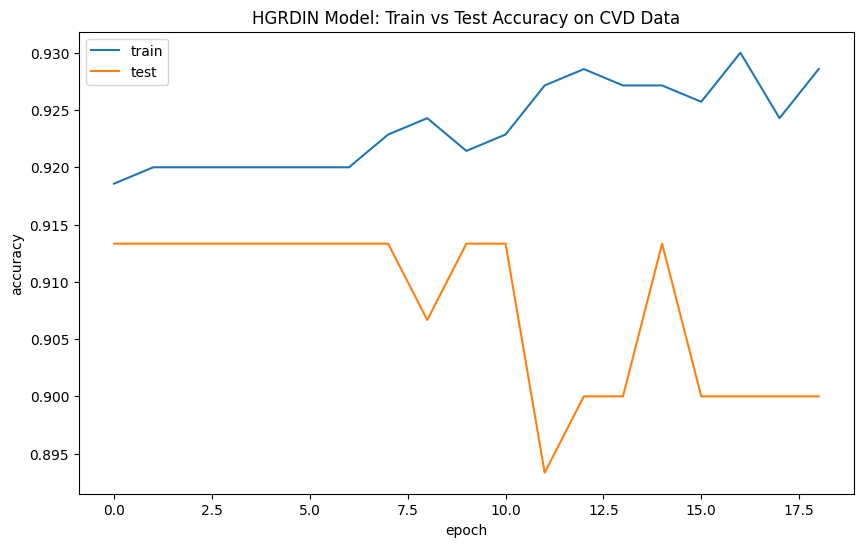

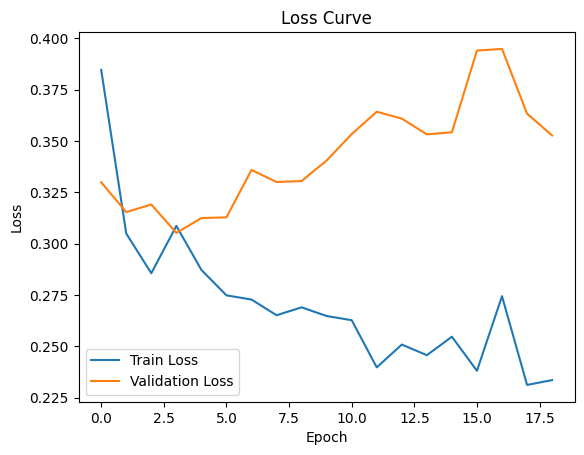

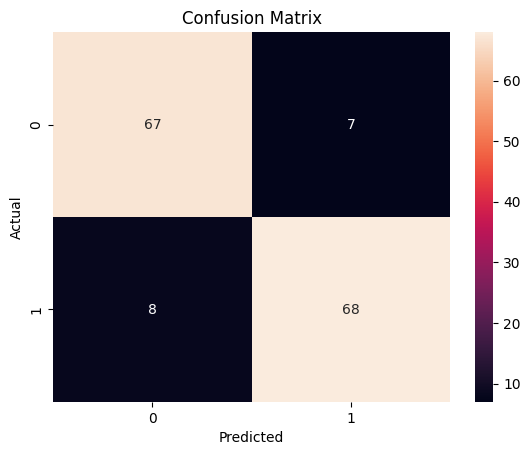

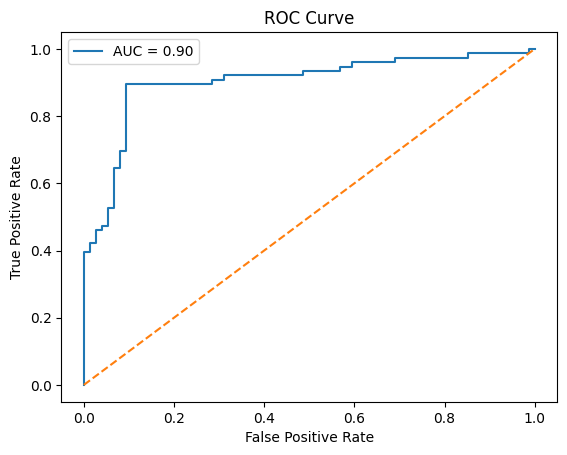

In [75]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "RSFS_results_0_cdm"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:

# X = encode_df[selected_rsfs].values
# y =  y.values

# X = encode_df[selected_rsfs].to_numpy()
# y =  y.to_numpy()

# =========================
# 3. Train / Val / Test Split
# =========================
 
X_train, X_temp , y_train, y_temp = train_test_split( X, y, test_size=0.3, random_state=42)
 

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
# ========================================================
# 13. Visualization: Train vs Test Accuracy (CVD Data)
# ========================================================

plt.figure(figsize=(10, 6))

# Plotting the lists collected during the training loop
plt.plot(train_acc_list, label='train')
plt.plot(val_acc_list, label='test') # Using val_acc_list as the 'test' proxy during training

# Labeling according to your provided chart style
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('HGRDIN Model: Train vs Test Accuracy on CVD Data')
plt.legend(loc='upper left')

# Optional: Match the y-axis starting point of your image (0.45 or 0.5)
# plt.ylim(bottom=0.45, top=1.0) 

plt.savefig(os.path.join(results_dir, "hgrdin_accuracy_comparison.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

## apdfs

In [76]:
X = encode_df.drop('CDM_Label', axis=1)
y= encode_df['CDM_Label']

In [77]:
import numpy as np

def apdfs(X, y, iterations=20):
    best_features = None
    best_score = 0
    
    for _ in range(iterations):
        prob = np.random.rand(X.shape[1])
        mask = prob > 0.5
        
        if sum(mask) == 0:
            continue
        
        selected = X.columns[mask]
        
        model = RandomForestClassifier()
        score = cross_val_score(model, X[selected], y, cv=3).mean()
        
        if score > best_score:
            best_score = score
            best_features = selected
            
    return best_features

selected_apdfs = apdfs(X, y)
print("APDFS Selected:", selected_apdfs)

APDFS Selected: Index(['Age', 'Gender', 'BMI', 'VisceralFat', 'HbA1c', 'BetaCellFunction',
       'PhysicalActivity', 'SmokingStatus', 'AlcoholConsumption', 'SystolicBP',
       'DiastolicBP', 'LDL', 'HDL', 'KidneyRisk', 'StressLevel', 'Uric_Acid',
       'InflammationMarker_CRP', 'ThyroidTSH', 'DietaryFiberIntake',
       'CarbIntake_gday'],
      dtype='object')


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test , y_train, y_test = train_test_split(encode_df[selected_apdfs], y, test_size=0.3, random_state=42)
scale = StandardScaler()
X_train, X_test = scale.fit_transform(X_train), scale.transform(X_test)

In [79]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN
    # =========================
    model.fit(X_train, y_train)


    # =========================
    # PREDICT
    # =========================
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "fpr": fpr,
        "tpr": tpr
    }


    tn, fp, fn, tp = cm.ravel()

    # Sensitivity, Hit Rate, or Recall
    tpr = tp / (tp + fn)

    # Fall-out or Probability of False Alarm
    fpr = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name


# =========================
# AFTER LOOP
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)



──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8861
False Positive Rate (FPR): 0.0704

Accuracy  : 0.9067
Precision : 0.9333
Recall    : 0.8861
F1-Score  : 0.9091
ROC-AUC   : 0.9092

Confusion Matrix:
[[132  10]
 [ 18 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       142
           1       0.93      0.89      0.91       158

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.7722
False Positive Rate (FPR): 0.1690

Accuracy  : 0.8000
Precision : 0.8356
Recall    : 0.7722
F1-Score  : 0.8026
ROC-AUC   : 0.8016

Confusion Matrix:
[[118  24]
 [ 36 

In [86]:
X = encode_df[selected_sdfs].to_numpy()
y =  df['CDM_Label'].to_numpy()

Epoch 10, Train Loss: 0.2545, Val Loss: 0.3673
Early stopping at epoch: 16

Threshold Tuning:
Threshold 0.30: Accuracy 0.8933
Threshold 0.35: Accuracy 0.8933
Threshold 0.40: Accuracy 0.8933
Threshold 0.45: Accuracy 0.8867
Threshold 0.50: Accuracy 0.8867
Threshold 0.55: Accuracy 0.8867
Threshold 0.60: Accuracy 0.8800
Threshold 0.65: Accuracy 0.8800
Threshold 0.70: Accuracy 0.8733
Threshold 0.75: Accuracy 0.8667

Best Threshold: 0.30

Final Results:
Accuracy: 0.8933333333333333

Confusion Matrix:
[[66  8]
 [ 8 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89        74
         1.0       0.89      0.89      0.89        76

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150


ROC-AUC Score:
0.9276315789473685
True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.1081
Precision: 0.8947
Recall:  

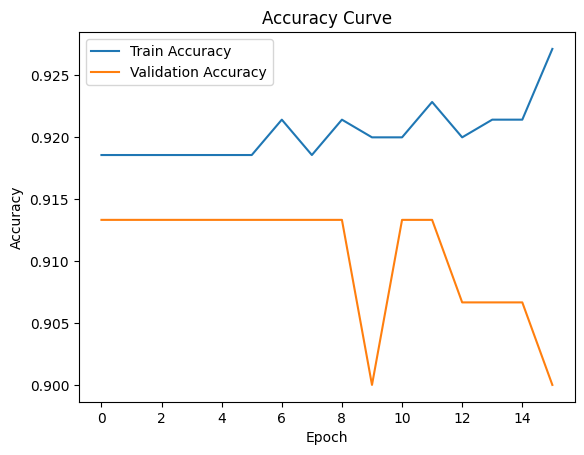

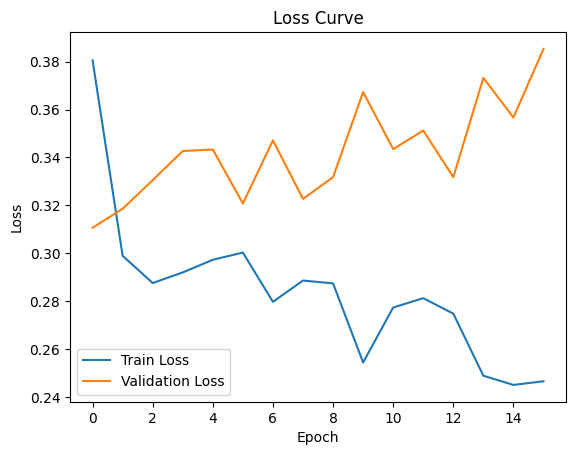

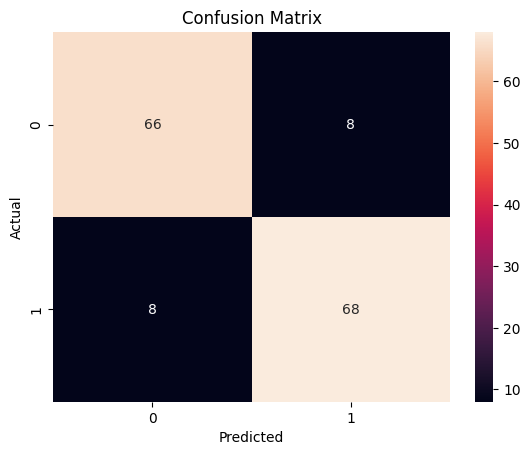

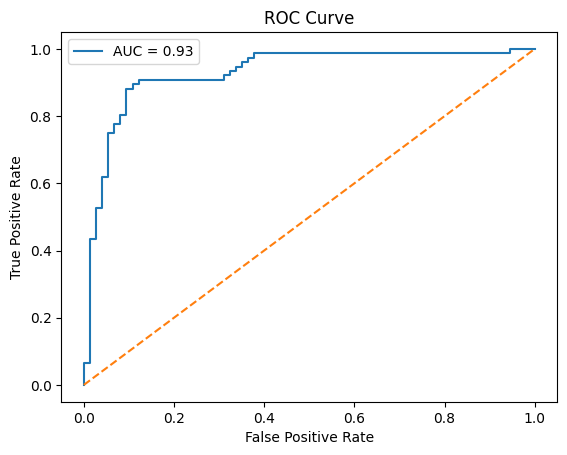

In [85]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "APDFS_results_0_CDM"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()

## deep leaning

In [80]:
X = encode_df[selected_sdfs].to_numpy()
y =  df['CDM_Label'].to_numpy()

Epoch 10, Train Loss: 0.3449, Val Loss: 0.2907
Epoch 20, Train Loss: 0.3052, Val Loss: 0.2912
Early stopping at epoch: 24

Threshold Tuning:
Threshold 0.30: Accuracy 0.9000
Threshold 0.35: Accuracy 0.9000
Threshold 0.40: Accuracy 0.9000
Threshold 0.45: Accuracy 0.9000
Threshold 0.50: Accuracy 0.9000
Threshold 0.55: Accuracy 0.9000
Threshold 0.60: Accuracy 0.9000
Threshold 0.65: Accuracy 0.9000
Threshold 0.70: Accuracy 0.9000
Threshold 0.75: Accuracy 0.8867

Best Threshold: 0.30

Final Results:
Accuracy: 0.9

Confusion Matrix:
[[67  7]
 [ 8 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90        74
         1.0       0.91      0.89      0.90        76

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150

True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.0946

ROC-AUC Score:
0.900248933143

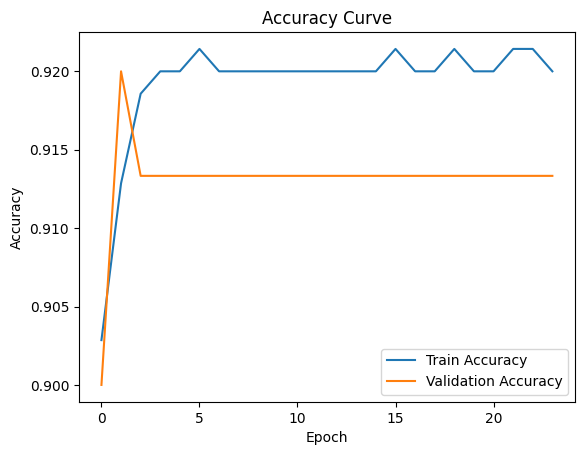

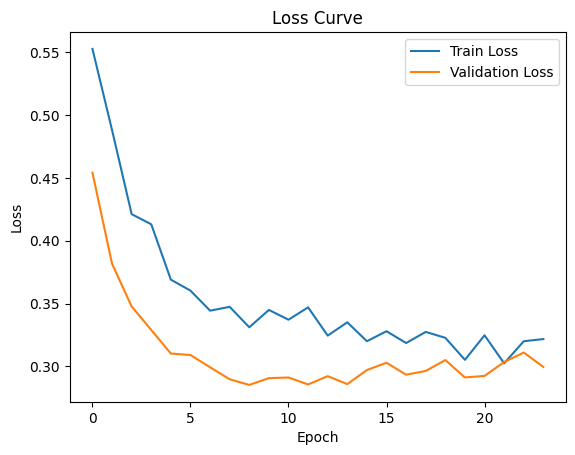

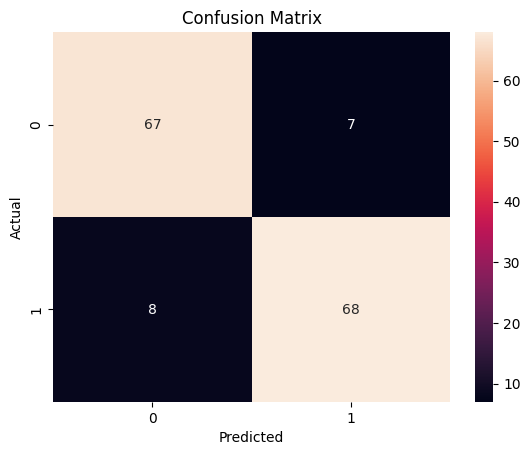

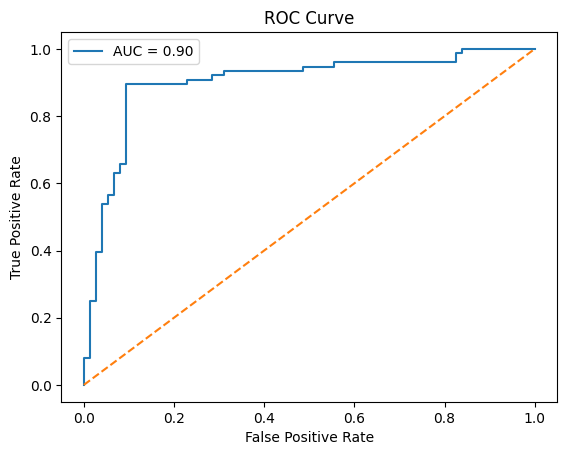

In [93]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score


import os

# Create results folder
results_dir = "results_cdm"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# =========================
class CVDModel(nn.Module):
    def __init__(self, input_size):  # ← accept input_size as parameter
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, 1)   # output
        )
    def forward(self, x):
        return self.net(x)

# Instantiate with the actual number of features
model = CVDModel(input_size=X_train.shape[1])   

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))


# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()
# start_time = time.time()
# # Your code here
# print(f"Elapsed: {time.time() - start_time} seconds")

Epoch 10, Train Loss: 0.2941, Val Loss: 0.3201
Epoch 20, Train Loss: 0.2631, Val Loss: 0.3782
Early stopping at epoch: 27

Threshold Tuning:
Threshold 0.30: Accuracy 0.8933
Threshold 0.35: Accuracy 0.8933
Threshold 0.40: Accuracy 0.9000
Threshold 0.45: Accuracy 0.9000
Threshold 0.50: Accuracy 0.9000
Threshold 0.55: Accuracy 0.8933
Threshold 0.60: Accuracy 0.8867
Threshold 0.65: Accuracy 0.8800
Threshold 0.70: Accuracy 0.8733
Threshold 0.75: Accuracy 0.8600

Best Threshold: 0.40

Final Results:
Accuracy: 0.9

Confusion Matrix:
[[67  7]
 [ 8 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90        74
         1.0       0.91      0.89      0.90        76

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150


ROC-AUC Score:
0.915184921763869
True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.0

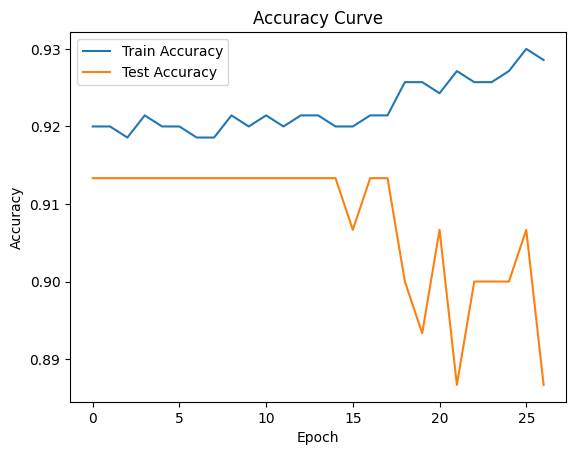

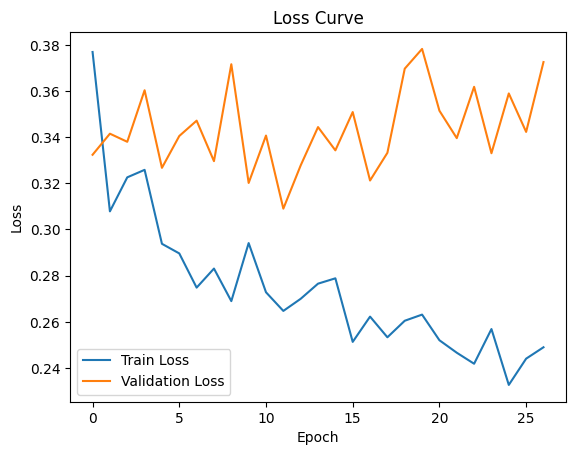

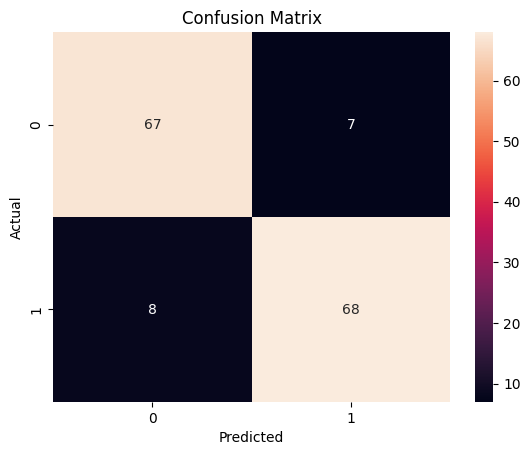

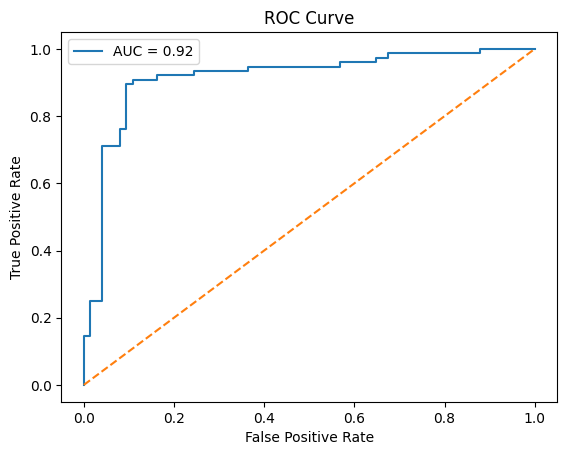

Elapsed: 0.004036903381347656 seconds


In [94]:
#=========================
# 1. Import Libraries
# =========================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F  # Add this to your imports at the top

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score, f1_score

import os

# Create results folder
results_dir = "results_0_cdm"
os.makedirs(results_dir, exist_ok=True)

# =========================
# 2. Load Data (Example)
# =========================
# Replace with your dataset
# df = pd.read_csv("your_dataset.csv")

# Example assumption:
# X = df.drop("target", axis=1).values
# y = df["target"].values

# =========================
# 3. Train / Val / Test Split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# =========================
# 5. Convert to Tensor
# =========================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val   = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# =========================
# 6. DataLoader (Batching)
# =========================
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ========================================================
# 7. HGRDIN Model Architecture (Updated)
# ========================================================


class GatedResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.25):
        super().__init__()
        
        # Main Transformation Path
        self.fc = nn.Linear(in_features, out_features)
        self.bn = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Gating Mechanism
        self.gate = nn.Linear(in_features, out_features)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        
        # Transformation
        out = self.fc(x)
        out = self.bn(out)
        out = F.relu(out)  # Changed from self.relu(out) to F.relu(out)
        out = self.dropout(out)
        
        # Apply Gating (Sigmoid mask)
        gate_weights = torch.sigmoid(self.gate(x))
        out = out * gate_weights
        
        # Hierarchical Interconnection
        return out + residual
# 1. Keep the GatedResidualBlock as defined
# 2. Re-add the HGRDIN wrapper class:
class HGRDIN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.init_layer = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.block1 = GatedResidualBlock(64, 64, dropout_rate=0.2)
        self.block2 = GatedResidualBlock(64, 32, dropout_rate=0.25)
        self.block3 = GatedResidualBlock(32, 16, dropout_rate=0.3)
        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.init_layer(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# 3. Instantiate the wrapper:
model = HGRDIN(input_size=X_train.shape[1])

# =========================
# 8. Loss + Optimizer
# =========================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 9. Training (Early Stopping)
# =========================
best_val_loss = float('inf')
best_model = model.state_dict()

patience = 15
counter = 0
epochs = 100

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):

    # -------- Train --------
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    # -------- Accuracy --------
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train))
        train_preds = (train_probs > 0.5).float()

        val_probs = torch.sigmoid(val_outputs)
        val_preds = (val_probs > 0.5).float()

        train_acc = accuracy_score(y_train.numpy(), train_preds.numpy())
        val_acc   = accuracy_score(y_val.numpy(), val_preds.numpy())

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss.item())

    # -------- Early Stopping --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping at epoch:", epoch+1)
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
model.load_state_dict(best_model)

# =========================
# 10. Evaluation
# =========================
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.sigmoid(test_logits)

# =========================
# 11. Threshold Tuning
# =========================
print("\nThreshold Tuning:")
thresholds = np.arange(0.3, 0.8, 0.05)

best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (test_probs > t).float()
    acc = accuracy_score(y_test.numpy(), preds.numpy())
    print(f"Threshold {t:.2f}: Accuracy {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f}")

test_preds = (test_probs > best_threshold).float()

# =========================
# 12. Final Metrics
# =========================
print("\nFinal Results:")
print("Accuracy:", accuracy_score(y_test.numpy(), test_preds.numpy()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
print(cm)

print("\nClassification Report:")
print(classification_report(y_test.numpy(), test_preds.numpy()))

print("\nROC-AUC Score:")
roc_auc = roc_auc_score(y_test.numpy(), test_probs.numpy())
print(roc_auc)


tn, fp, fn, tp = cm.ravel()

# Flatten the matrix to get individual components
tn, fp, fn, tp = cm.ravel()

# Sensitivity, Hit Rate, or Recall
tpr = tp / (tp + fn)

# Fall-out or Probability of False Alarm
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR):  {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

precision = precision_score(y_test.numpy(), test_preds.numpy())
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test.numpy(), test_preds.numpy())
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test.numpy(), test_preds.numpy())
print(f"F1-Score:  {f1:.4f}")

# =========================
# 13. Visualization (SAVE)
# =========================

# ---- Accuracy Curve ----
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Test Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.savefig(os.path.join(results_dir, "accuracy_curve.png"), dpi=300)
plt.show()


# ---- Loss Curve ----
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(os.path.join(results_dir, "loss_curve.png"), dpi=300)
plt.show()


# ---- Confusion Matrix ----
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(results_dir, "confusion_matrix.png"), dpi=300)
plt.show()


# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test.numpy(), test_probs.numpy())

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(os.path.join(results_dir, "roc_curve.png"), dpi=300)
plt.show()
import time

start_time = time.time()
# Your code here
print(f"Elapsed: {time.time() - start_time} seconds")

# In Jupyter/IPython notebooks:
# %time print("Hello")  # Measures one line
# %%time                # Put at top of cell to measure entire cell

In [83]:

# =========================
# 5. Training Function
# =========================
def train_model(X_train_np, y_train_np, X_val_np, y_val_np,
                input_size, epochs=100, patience=15,
                batch_size=16, lr=0.001):
    """Train HGRDIN and return best model + history."""
 
    # Scale
    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(X_train_np)
    X_vl    = scaler.transform(X_val_np)
 
    # Tensors
    Xtr = torch.tensor(X_tr, dtype=torch.float32)
    Xvl = torch.tensor(X_vl, dtype=torch.float32)
    ytr = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)
    yvl = torch.tensor(y_val_np,   dtype=torch.float32).view(-1, 1)
 
    loader = DataLoader(TensorDataset(Xtr, ytr),
                        batch_size=batch_size, shuffle=True)
 
    model     = HGRDIN(input_size)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
 
    best_val_loss = float('inf')
    best_state    = model.state_dict()
    counter       = 0
 
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []
 
    for epoch in range(epochs):
        # --- Train ---
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            out  = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_loss = epoch_loss / len(loader)
 
        # --- Validate ---
        model.eval()
        with torch.no_grad():
            val_out  = model(Xvl)
            val_loss = criterion(val_out, yvl).item()
 
            tr_probs = torch.sigmoid(model(Xtr))
            tr_preds = (tr_probs > 0.5).float()
            vl_probs = torch.sigmoid(val_out)
            vl_preds = (vl_probs > 0.5).float()
 
            tr_acc = accuracy_score(ytr.numpy(), tr_preds.numpy())
            vl_acc = accuracy_score(yvl.numpy(), vl_preds.numpy())
 
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(tr_acc)
        val_acc_hist.append(vl_acc)
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            counter       = 0
        else:
            counter += 1
        if counter >= patience:
            print(f"    Early stopping at epoch {epoch + 1}")
            break
 
    model.load_state_dict(best_state)
    return model, scaler, {
        "train_loss": train_loss_hist,
        "val_loss":   val_loss_hist,
        "train_acc":  train_acc_hist,
        "val_acc":    val_acc_hist,
    }
 
 
# =========================
# 6. Evaluation Function
# =========================
def evaluate_model(model, scaler, X_test_np, y_test_np):
    """Return full metrics dict for a test set."""
    X_sc = scaler.transform(X_test_np)
    Xts  = torch.tensor(X_sc, dtype=torch.float32)
    yts  = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)
 
    model.eval()
    with torch.no_grad():
        logits = model(Xts)
        probs  = torch.sigmoid(logits)
 
    # Threshold tuning on the test set
    best_acc, best_thresh = 0, 0.5
    for t in np.arange(0.3, 0.8, 0.05):
        preds = (probs > t).float()
        acc   = accuracy_score(yts.numpy(), preds.numpy())
        if acc > best_acc:
            best_acc, best_thresh = acc, t
 
    preds = (probs > best_thresh).float()
    cm    = confusion_matrix(yts.numpy(), preds.numpy())
    tn, fp, fn, tp = cm.ravel()
 
    return {
        "accuracy":  accuracy_score(yts.numpy(), preds.numpy()),
        "precision": precision_score(yts.numpy(), preds.numpy(), zero_division=0),
        "recall":    recall_score(yts.numpy(), preds.numpy(), zero_division=0),
        "f1":        f1_score(yts.numpy(), preds.numpy(), zero_division=0),
        "roc_auc":   roc_auc_score(yts.numpy(), probs.numpy()),
        "tpr":       tp / (tp + fn) if (tp + fn) > 0 else 0,
        "fpr":       fp / (fp + tn) if (fp + tn) > 0 else 0,
        "threshold": best_thresh,
        "cm":        cm,
        "probs":     probs.numpy(),
        "y_true":    yts.numpy(),
    }
 
 
# =========================
# 7. Run All Splits
# =========================
SPLITS = [
    (0.70, 0.30),   # 70 / 30
    (0.60, 0.40),   # 60 / 40
    (0.80, 0.20),   # 80 / 20
    (0.50, 0.50),   # 50 / 50
    (0.65, 0.35),   # 65 / 35
]
 
all_results  = {}   # metrics per split
all_history  = {}   # loss/acc curves per split
 
for train_ratio, test_ratio in SPLITS:
    label = f"{int(train_ratio*100)}/{int(test_ratio*100)}"
    print(f"\n{'='*50}")
    print(f"  Split: {label}")
    print(f"{'='*50}")
 
    # ---- Split ----
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42
    )
    # Use 15 % of train as validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.15, random_state=42
    )
 
    print(f"  Train: {len(X_tr):4d}  Val: {len(X_val):4d}  Test: {len(X_test):4d}")
 
    # ---- Train ----
    model, scaler, history = train_model(
        X_tr, y_tr, X_val, y_val,
        input_size=X.shape[1]
    )
 
    # ---- Evaluate ----
    metrics = evaluate_model(model, scaler, X_test, y_test)
    all_results[label] = metrics
    all_history[label] = history
 
    print(f"  Accuracy : {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall   : {metrics['recall']:.4f}")
    print(f"  F1-Score : {metrics['f1']:.4f}")
    print(f"  ROC-AUC  : {metrics['roc_auc']:.4f}")
    print(f"  Threshold: {metrics['threshold']:.2f}")
 
 
# =========================
# 8. Summary Table
# =========================
summary_rows = []
for label, m in all_results.items():
    summary_rows.append({
        "Split":     label,
        "Accuracy":  round(m["accuracy"],  4),
        "Precision": round(m["precision"], 4),
        "Recall":    round(m["recall"],    4),
        "F1-Score":  round(m["f1"],        4),
        "ROC-AUC":   round(m["roc_auc"],   4),
        "TPR":       round(m["tpr"],       4),
        "FPR":       round(m["fpr"],       4),
        "Threshold": round(m["threshold"], 2),
    })
 


  Split: 70/30
  Train:  595  Val:  105  Test:  300
    Early stopping at epoch 23
  Accuracy : 0.9067
  Precision: 0.9333
  Recall   : 0.8861
  F1-Score : 0.9091
  ROC-AUC  : 0.9085
  Threshold: 0.35

  Split: 60/40
  Train:  510  Val:   90  Test:  400
    Early stopping at epoch 22
  Accuracy : 0.9025
  Precision: 0.9072
  Recall   : 0.8934
  F1-Score : 0.9003
  ROC-AUC  : 0.8993
  Threshold: 0.45

  Split: 80/20
  Train:  680  Val:  120  Test:  200
    Early stopping at epoch 26
  Accuracy : 0.9050
  Precision: 0.9271
  Recall   : 0.8812
  F1-Score : 0.9036
  ROC-AUC  : 0.9140
  Threshold: 0.35

  Split: 50/50
  Train:  425  Val:   75  Test:  500
    Early stopping at epoch 38
  Accuracy : 0.9000
  Precision: 0.8960
  Recall   : 0.9032
  F1-Score : 0.8996
  ROC-AUC  : 0.9064
  Threshold: 0.35

  Split: 65/35
  Train:  552  Val:   98  Test:  350
    Early stopping at epoch 21
  Accuracy : 0.9000
  Precision: 0.9176
  Recall   : 0.8814
  F1-Score : 0.8991
  ROC-AUC  : 0.8895
  Thresh

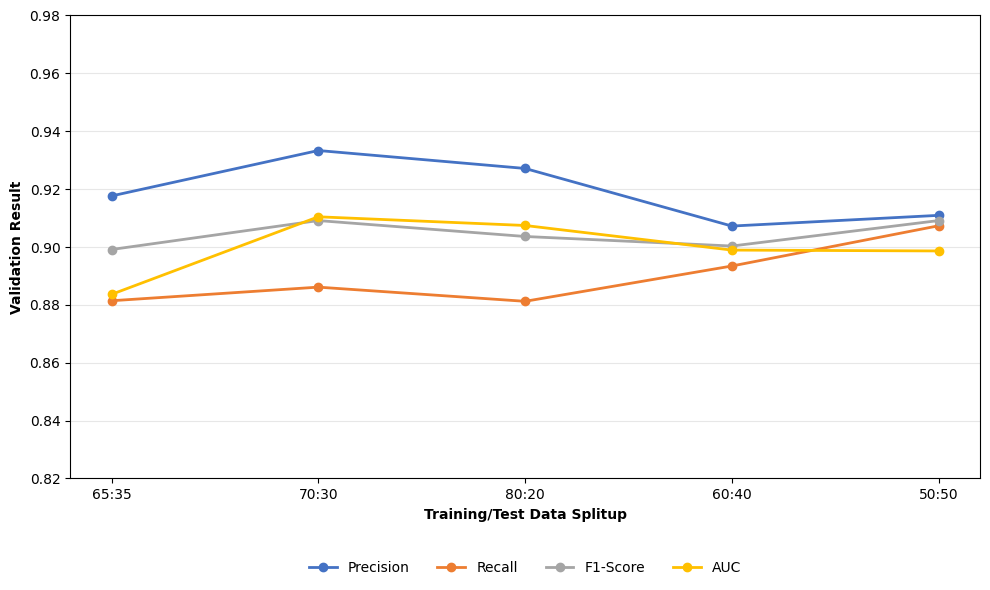

In [84]:
import matplotlib.pyplot as plt

# 1. Define the Data Labels (Ordered as per your image)
splits = ['65:35', '70:30', '80:20', '60:40', '50:50']

# Updated metrics from your latest data
precision = [0.9176, 0.9333, 0.9271, 0.9072, 0.9109]
recall    = [0.8814, 0.8861, 0.8812, 0.8934, 0.9073]
f1_score  = [0.8991, 0.9091, 0.9036, 0.9003, 0.9091]
auc       = [0.8836, 0.9104, 0.9074, 0.8989, 0.8986]

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Plotting each line with markers
plt.plot(splits, precision, marker='o', label='Precision', color='#4472c4', linewidth=2)
plt.plot(splits, recall,    marker='o', label='Recall',    color='#ed7d31', linewidth=2)
plt.plot(splits, f1_score,  marker='o', label='F1-Score',  color='#a5a5a5', linewidth=2)
plt.plot(splits, auc,       marker='o', label='AUC',       color='#ffc000', linewidth=2)

# 4. Formatting (Matching your style)
plt.xlabel('Training/Test Data Splitup', fontweight='bold')
plt.ylabel('Validation Result', fontweight='bold')
plt.ylim(0.82, 0.98)  # Setting the Y-axis range to match your image
plt.grid(axis='y', linestyle='-', alpha=0.3)

# Place legend at the bottom
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
plt.savefig(os.path.join(results_dir, "spliting.png"), dpi=300)

plt.tight_layout()
plt.show()

In [88]:
import numpy as np
import pandas as pd
import time  # Added for timing
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

results = {}
best_model_name = None
best_auc = 0

for name, model in models.items():

    print(f"\n{'─'*50}")
    print(f"Model: {name}")
    print(f"{'─'*50}")

    # =========================
    # TRAIN (With Timing)
    # =========================
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    end_train = time.perf_counter()
    train_duration = end_train - start_train

    # =========================
    # PREDICT (With Timing)
    # =========================
    start_test = time.perf_counter()
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    end_test = time.perf_counter()
    test_duration = end_test - start_test

    # =========================
    # METRICS
    # =========================
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr_list, tpr_list, _ = roc_curve(y_test, y_pred_prob)

    # Store results including time
    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4),
        "Train Time": round(train_duration, 4),
        "Test Time": round(test_duration, 4),
        "fpr": fpr_list,
        "tpr": tpr_list
    }

    tn, fp, fn, tp = cm.ravel()
    tpr_val = tp / (tp + fn)
    fpr_val = fp / (fp + tn)

    print(f"True Positive Rate (TPR):  {tpr_val:.4f}")
    print(f"False Positive Rate (FPR): {fpr_val:.4f}")

    # Print Time Results
    print(f"Training Time : {train_duration:.4f} sec")
    print(f"Testing Time  : {test_duration:.4f} sec")

    print(f"\nAccuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    # =========================
    # BEST MODEL TRACKING
    # =========================
    if auc > best_auc:
        best_auc = auc
        best_model_name = name

# =========================
# AFTER LOOP: Summary Table
# =========================
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"AUC Score   : {best_auc:.4f}")
print("="*60)

# Optional: Display time comparison table
time_df = pd.DataFrame.from_dict(results, orient='index')[['Train Time', 'Test Time', 'AUC']]
print("\nModel Time Comparison:")
print(time_df)


──────────────────────────────────────────────────
Model: Logistic Regression
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.0946
Training Time : 0.1123 sec
Testing Time  : 0.0101 sec

Accuracy  : 0.9000
Precision : 0.9067
Recall    : 0.8947
F1-Score  : 0.9007
ROC-AUC   : 0.8949

Confusion Matrix:
[[67  7]
 [ 8 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90        74
         1.0       0.91      0.89      0.90        76

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150


──────────────────────────────────────────────────
Model: dt
──────────────────────────────────────────────────


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



True Positive Rate (TPR):  0.8289
False Positive Rate (FPR): 0.1757
Training Time : 0.0324 sec
Testing Time  : 0.0025 sec

Accuracy  : 0.8267
Precision : 0.8289
Recall    : 0.8289
F1-Score  : 0.8289
ROC-AUC   : 0.8266

Confusion Matrix:
[[61 13]
 [13 63]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82        74
         1.0       0.83      0.83      0.83        76

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150


──────────────────────────────────────────────────
Model: gnb
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.0946
Training Time : 0.0283 sec
Testing Time  : 0.0126 sec

Accuracy  : 0.9000
Precision : 0.9067
Recall    : 0.8947
F1-Score  : 0.9007
ROC-AUC   : 0.8863

Confusion Matrix:
[[67  7]
 [ 8 68]]

Classification Report:

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().




Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90        74
         1.0       0.91      0.89      0.90        76

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150


──────────────────────────────────────────────────
Model: Random Forest
──────────────────────────────────────────────────


c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.0946
Training Time : 0.3878 sec
Testing Time  : 0.0286 sec

Accuracy  : 0.9000
Precision : 0.9067
Recall    : 0.8947
F1-Score  : 0.9007
ROC-AUC   : 0.8933

Confusion Matrix:
[[67  7]
 [ 8 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90        74
         1.0       0.91      0.89      0.90        76

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150


──────────────────────────────────────────────────
Model: KNN
──────────────────────────────────────────────────
True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.0811
Training Time : 0.0438 sec
Testing Time  : 0.0513 sec

Accuracy  : 0.9067
Precision : 0.9189
Recall    : 0.8947
F1-Score  : 0.9067
ROC-AUC   : 0.8931

Confusion Matrix:
[[68  6]
 [ 8 68]]

Classification Report:

c:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



True Positive Rate (TPR):  0.8947
False Positive Rate (FPR): 0.1081
Training Time : 0.5687 sec
Testing Time  : 0.0250 sec

Accuracy  : 0.8933
Precision : 0.8947
Recall    : 0.8947
F1-Score  : 0.8947
ROC-AUC   : 0.8956

Confusion Matrix:
[[66  8]
 [ 8 68]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89        74
         1.0       0.89      0.89      0.89        76

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150


🏆 BEST MODEL: SVM
AUC Score   : 0.9063

Model Time Comparison:
                     Train Time  Test Time     AUC
Logistic Regression      0.1123     0.0101  0.8949
dt                       0.0324     0.0025  0.8266
gnb                      0.0283     0.0126  0.8863
SVM                      0.0645     0.0063  0.9063
Random Forest            0.3878     0.0286  0.8933
KNN                    